In [1]:
"""
📘 THEORETICAL ANSWERS (copy-paste ready)



1. What does R-squared represent?

R² shows how much variation in the dependent variable is explained by the model.




2. Assumptions of Linear Regression
Linearity
Independence
Homoscedasticity
Normal distribution of errors
No multicollinearity



3. R² vs Adjusted R²
R² increases with more variables
Adjusted R² adjusts for unnecessary variables



4. Why use MSE?

MSE measures average squared error and penalizes large errors.




5. Adjusted R² = 0.85 means

85% of variance is explained after adjusting for variables.





6. Check normality of residuals
Histogram
Q-Q plot
Shapiro test




7. Multicollinearity

When independent variables are highly correlated → affects coefficients.





8. MAE

Mean of absolute errors between actual and predicted values.





9. Benefits of ML Pipeline
Automation
Cleaner workflow
Reduces errors




10. Why RMSE more interpretable?

Because it is in same unit as target variable.




11. Pickling in Python

Saving trained model to file for reuse.




12. High R² means

Model fits data well (but not always perfect).






13. If assumptions violated

Model becomes unreliable.





14. Fix multicollinearity
Remove features
PCA
Ridge regression





15. Feature selection benefits
Improves accuracy
Reduces overfitting




16. Adjusted R² formula

Adjusted R^2 = (1−R^2)(n−1)/n-k-1
	​


17. Why MSE sensitive to outliers?

Because errors are squared.




18. Role of homoscedasticity

Ensures constant error variance → reliable model.




19. RMSE

Square root of MSE → easier interpretation.




20. Why pickling risky?
Security issues
Version mismatch




21. Alternatives to pickling
Joblib
ONNX





22. Heteroscedasticity

Unequal error variance → bad predictions.




23. Interaction terms

Capture combined effect of variables."""

'\n📘 THEORETICAL ANSWERS (copy-paste ready)\n\n\n\n1. What does R-squared represent?\n\nR² shows how much variation in the dependent variable is explained by the model.\n\n\n\n\n2. Assumptions of Linear Regression\nLinearity\nIndependence\nHomoscedasticity\nNormal distribution of errors\nNo multicollinearity\n\n\n\n3. R² vs Adjusted R²\nR² increases with more variables\nAdjusted R² adjusts for unnecessary variables\n\n\n\n4. Why use MSE?\n\nMSE measures average squared error and penalizes large errors.\n\n\n\n\n5. Adjusted R² = 0.85 means\n\n85% of variance is explained after adjusting for variables.\n\n\n\n\n\n6. Check normality of residuals\nHistogram\nQ-Q plot\nShapiro test\n\n\n\n\n7. Multicollinearity\n\nWhen independent variables are highly correlated → affects coefficients.\n\n\n\n\n\n8. MAE\n\nMean of absolute errors between actual and predicted values.\n\n\n\n\n\n9. Benefits of ML Pipeline\nAutomation\nCleaner workflow\nReduces errors\n\n\n\n\n10. Why RMSE more interpretable?\

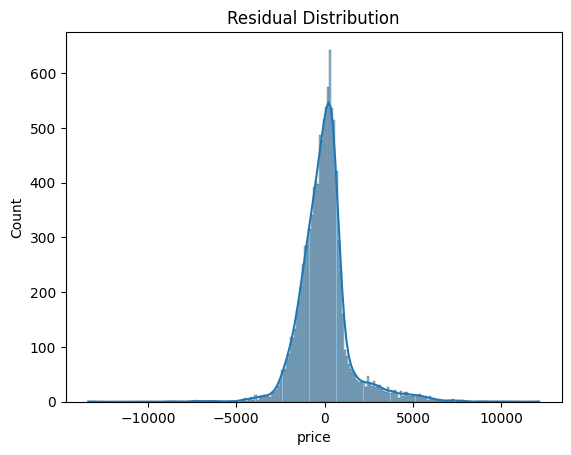

In [2]:
#✅ Practical 1: Residual Distribution (diamonds dataset):

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
data = sns.load_dataset('diamonds')

X = data[['carat', 'depth', 'table']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [3]:
#✅ Practical 2: MSE, MAE, RMSE:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 2250138.5007395
MAE: 983.1013942950018
RMSE: 1500.0461662027271


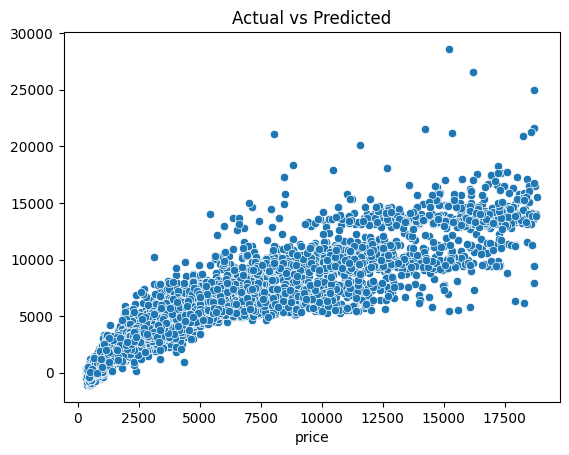

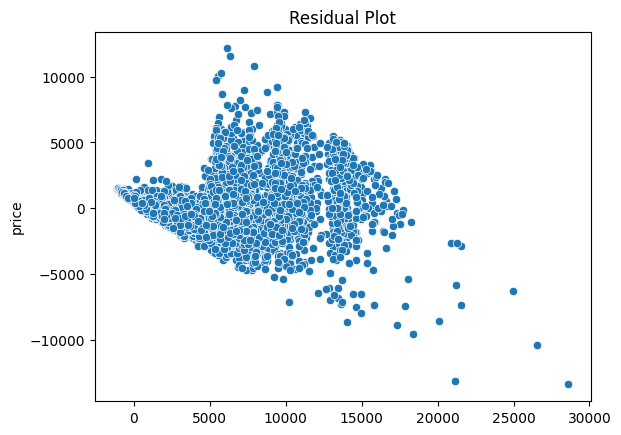

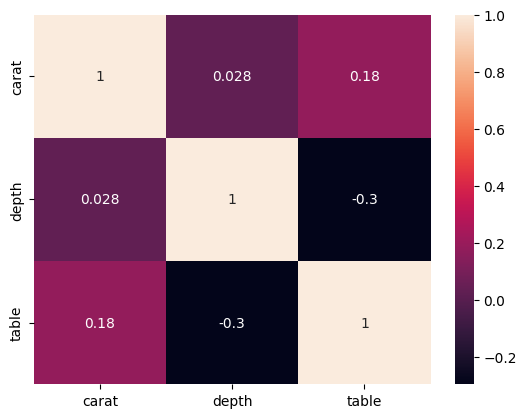

In [4]:
#✅ Practical 3: Check assumptions:

import matplotlib.pyplot as plt
import seaborn as sns

# Linearity check
sns.scatterplot(x=y_test, y=y_pred)
plt.title("Actual vs Predicted")
plt.show()

# Residual plot
sns.scatterplot(x=y_pred, y=residuals)
plt.title("Residual Plot")
plt.show()

# Correlation matrix
sns.heatmap(X.corr(), annot=True)
plt.show()

In [5]:
#✅ Practical 4: ML Pipeline:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
print("R2 Score:", pipeline.score(X_test, y_test))

R2 Score: 0.8550968339853171


In [6]:
#✅ Practical 5: Simple Linear Regression:

from sklearn.metrics import r2_score

X_simple = data[['carat']]
y_simple = data['price']

model = LinearRegression()
model.fit(X_simple, y_simple)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

y_pred = model.predict(X_simple)
print("R2 Score:", r2_score(y_simple, y_pred))

Coefficient: [7756.42561797]
Intercept: -2256.360580045403
R2 Score: 0.8493305264354858


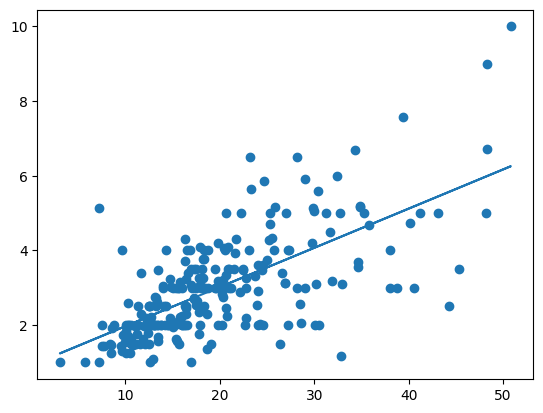

In [7]:
#✅ Practical 6 (tips dataset):
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = sns.load_dataset('tips')

X = data[['total_bill']]
y = data['tip']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

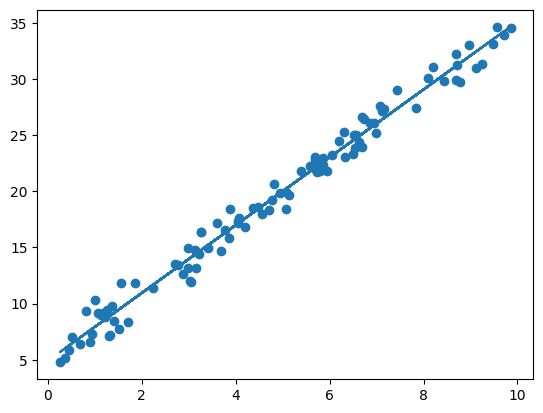

In [8]:
#✅ Practical 7: Synthetic Data + Plot:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(100,1) * 10
y = 3*X + 5 + np.random.randn(100,1)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

In [9]:
#✅ Practical 8: Pickle Model:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Load
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

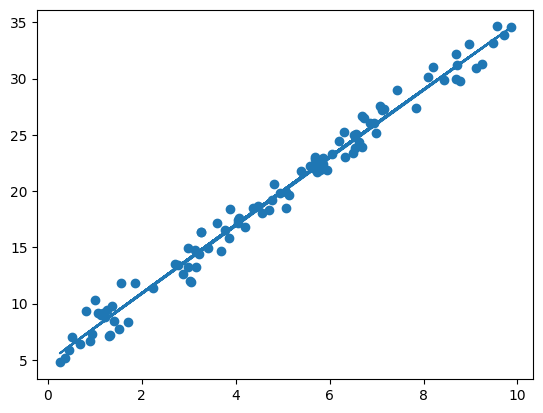

In [10]:
#✅ Practical 9: Polynomial Regression:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

In [11]:
#✅ Practical 10 (random data):
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.random.rand(100,1)
y = 4*X + 2

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[4.]]
Intercept: [2.]


In [12]:
#✅ Practical 11 (different degrees):
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

for d in [1,2,3]:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    print("Degree", d, "R2:", r2_score(y, y_pred))

Degree 1 R2: 1.0
Degree 2 R2: 1.0
Degree 3 R2: 1.0


In [13]:
#✅ Practical 12 (2 features):
X = np.random.rand(100,2)
y = X[:,0]*3 + X[:,1]*2

model = LinearRegression()
model.fit(X, y)

print(model.coef_, model.intercept_)

[3. 2.] 1.3322676295501878e-15


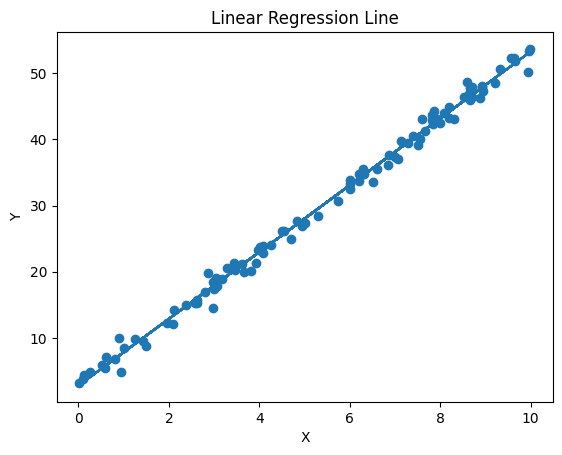

In [14]:
#✅ Practical 13: Generate data + Linear Regression + Visualization:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic data
X = np.random.rand(100, 1) * 10
y = 5 * X + 3 + np.random.randn(100, 1)

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Line")
plt.show()

In [16]:
#✅ Practical 14: VIF (Multicollinearity):
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create DataFrame (IMPORTANT)
X = pd.DataFrame(np.random.rand(100,3), columns=['A','B','C'])

# VIF calculation
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  feature       VIF
0       A  2.754452
1       B  2.697799
2       C  3.155563


In [17]:
#✅ Practical 15 (degree 4):
X = np.linspace(-3,3,100).reshape(-1,1)
y = X**4 + X**3 + np.random.randn(100,1)

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model.fit(X_poly, y)

LinearRegression()

In [18]:
#✅ Practical 16 (pipeline):
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X, y)
print(pipe.score(X, y))

0.14920964242880796


In [19]:
#✅ Practical 17 (degree 3):
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model.fit(X_poly, y)

LinearRegression()

In [20]:
#✅ Practical 18 (5 features):
X = np.random.rand(100,5)
y = np.sum(X, axis=1)

model.fit(X, y)
print(model.coef_)

[1. 1. 1. 1. 1.]


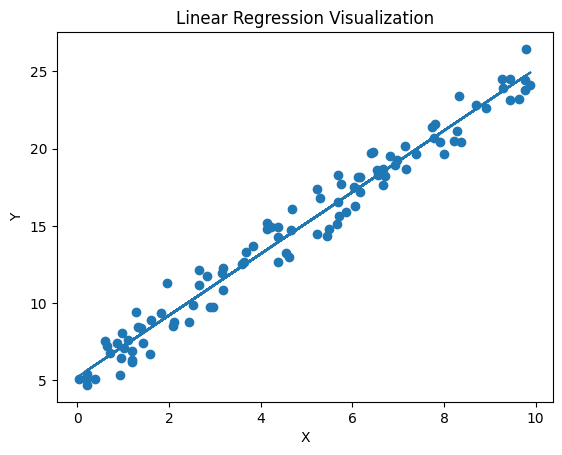

In [21]:
#✅ Practical 19: Generate data + Linear Regression + Visualization:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X + 5 + np.random.randn(100, 1)

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Plot data points
plt.scatter(X, y)

# Plot regression line
plt.plot(X, y_pred)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Visualization")
plt.show()

In [22]:
#✅ Practical 20 (3 features):
X = np.random.rand(100,3)
y = X[:,0] + X[:,1]*2 + X[:,2]*3

model.fit(X, y)
print(model.coef_)

[1. 2. 3.]


In [23]:
#✅ Practical 21: Joblib (better than pickle):
import joblib

joblib.dump(model, "model.joblib")

loaded_model = joblib.load("model.joblib")

In [24]:
#✅ Practical 22 (categorical):
data = sns.load_dataset('tips')

data = pd.get_dummies(data, drop_first=True)

X = data.drop('tip', axis=1)
y = data['tip']

model.fit(X, y)

LinearRegression()

In [25]:
#✅ Practical 23 (Ridge vs Linear):
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X, y)

print("Ridge:", ridge.coef_)
print("Linear:", model.coef_)

Ridge: [ 0.09444287  0.17543019  0.03130795  0.08304953  0.1267268  -0.00076844
  0.094863   -0.03026345]
Linear: [ 0.09448701  0.175992    0.03244094  0.08640832  0.1622592   0.04080082
  0.13677854 -0.0681286 ]


In [26]:
#✅ Practical 24 (cross-validation):
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.4214266405944052


In [27]:
#✅ Practical 25 (compare polynomial):
for d in [1,2,3,4]:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model.fit(X_poly, y)
    print("Degree", d, model.score(X_poly, y))

Degree 1 0.47007812322060794
Degree 2 0.5698957845789635
Degree 3 0.6978304120589722
Degree 4 0.8172321957040416
